In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")

who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Nov2024_Tier1_V2.csv")

coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/isolate_WHO_catalog_variants.csv")

/tmp/ipykernel_9973/1482320330.py:9: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


# Isolates with MICs that Span the CC: How are they predicted?

In [2]:
drug = 'ETH'
drug_full_name = abbr_drug_dict[drug]

kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))

df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))[['ROLLINGDB_ID', 'Coll2014', 'Lineage', 'Binary']]

df = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv")).query("Span_CC==1")
df['pred_MIC'] = np.exp2(df['y_pred'])

df['pred_binary'] = (df['pred_MIC'] > cc_dict[drug]).astype(int)
print(f"{np.round(df['pred_binary'].mean(), 3)*100}% of {len(df)} isolates are predicted resistant to {drug_full_name}")

df_insilico_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", 'inSilico_analysis', kwargs['tier1_loci'][0], "test_predictions.csv"))
ref_pred = df_insilico_pred.query("ROLLINGDB_ID=='MT_H37Rv'").pred_MIC.values[0]

# add to the dataframe
df['ref_pred'] = ref_pred
df['fold_change'] = df['pred_MIC'] / df['ref_pred']
df['log_fold_change'] = np.log(df['fold_change'])

8.200000000000001% of 61 isolates are predicted resistant to Ethionamide


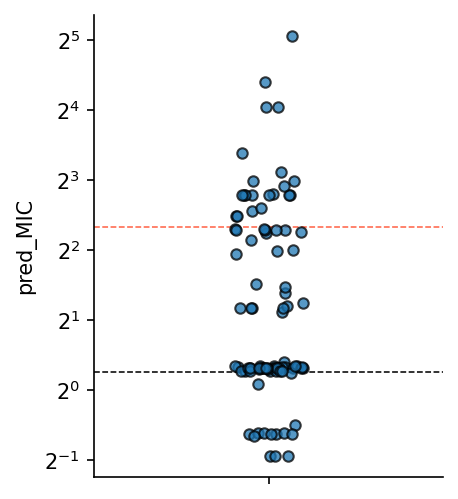

In [77]:
fig, ax = plt.subplots(figsize=(3, 4))

sns.stripplot(data=df,
              y='pred_MIC',
              log_scale=2,
              ax=ax,
              alpha=0.75,
              linewidth=1,
              edgecolor='black'
             )

# sns.histplot(data=df,
#               x='pred_MIC',
#               log_scale=2,
#               ax=ax,
#               alpha=0.75,
#               linewidth=1,
#               edgecolor='black'
#              )

plt.axhline(cc_dict[drug], color='tomato', linestyle='--', linewidth=0.75)
plt.axhline(ref_pred, color='black', linestyle='--', linewidth=0.75)

sns.despine()
plt.show()

# Isolates Predicted with Intermediate MICs: 1 doubling below CC

In [150]:
drug = 'EMB'
drug_full_name = abbr_drug_dict[drug]

kwargs = yaml.safe_load(open(f"config_files/config_{drug.lower()}.yaml", "r"))
df = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv")).rename(columns={'Isolate': 'ROLLINGDB_ID'})
df['pred_MIC'] = np.exp2(df['y_pred'])

# need to get the reference prediction. Should have saved that in test predictions, but oh well
df_insilico_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", 'inSilico_analysis', kwargs['tier1_loci'][0], "test_predictions.csv")).rename(columns={'ROLLINGDB_ID': 'variant'})
ref_pred = df_insilico_pred.query("variant=='MT_H37Rv'").pred_MIC.values[0]

# fix naming
df_insilico_pred['variant'] = df_insilico_pred['variant'].str.replace('_p_', '_p.').str.replace('_c_', '_c.').replace('+', '*')

# add to the dataframe
df['ref_pred'] = ref_pred
df['fold_change'] = df['pred_MIC'] / df['ref_pred']
df['log_fold_change'] = np.log(df['fold_change'])

df_intermediate_MIC = df.query("fold_change >= 0.5 & fold_change <= 1")
print(f"{len(df_intermediate_MIC)} isolates have a predicted MIC ≤ 1 doubling below the CC")

817 isolates have a predicted MIC ≤ 1 doubling below the CC


In [158]:
df_intermediate_MIC_variants = df_intermediate_MIC.merge(isolate_variants.query("drug==@drug_full_name"), on='ROLLINGDB_ID', how='left')

# get the most common variants that are not Group 1-2 variants for that drug
common_new_variants = pd.DataFrame(df_intermediate_MIC_variants.query("~confidence.str.contains('Assoc w R')")[['variant', 'confidence', 'ref_pred', 'fold_change', 'log_fold_change']].value_counts()).reset_index()

common_new_variants = common_new_variants.merge(df_insilico_pred, how='left')

In [166]:
common_new_variants.sort_values("pred_MIC", ascending=False)

,variant,confidence,ref_pred,fold_change,log_fold_change,count,log2_pred_MIC,pred_MIC
1427,embA_p.Pro1082Leu,3) Uncertain significance,1.246963,0.991055,-0.008985,1,0.529141,1.443070
251,embA_p.Gly884Asp,3) Uncertain significance,1.246963,0.812725,-0.207362,2,0.413709,1.332106
868,embA_c.1899G>A,4) Not assoc w R - Interim,1.246963,0.763833,-0.269406,1,0.400980,1.320405
1254,embB_p.Pro731Leu,3) Uncertain significance,1.246963,0.968202,-0.032315,1,0.380275,1.301590
261,embB_p.Pro731Leu,3) Uncertain significance,1.246963,0.972892,-0.027482,2,0.380275,1.301590
...,...,...,...,...,...,...,...,...
1197,Rv2752c_p.Leu191Pro,3) Uncertain significance,1.246963,0.996397,-0.003610,1,NaN,NaN
1198,Rv2752c_p.Ile453Thr,3) Uncertain significance,1.246963,0.995435,-0.004575,1,NaN,NaN
1336,Rv2477c_c.1434G>C,4) Not assoc w R - Interim,1.246963,0.654276,-0.424225,1,NaN,NaN
1404,embA_p.Val871dup,3) Uncertain significance,1.246963,0.980662,-0.019527,1,NaN,NaN


# Moxifloxacin and ethionamide: Which Isolates does lineage change predictions for?

In [3]:
def add_addl_data_pred_df(df):

    df["y_pred_exp"] = np.exp2(df["y_pred"])

    df.loc[df["y_pred_exp"] < df["lower"], "error"] = -1
    df.loc[df["y_pred_exp"] > df["upper"], "error"] = 1
    df["error"] = df["error"].fillna(0).astype(int)

    df.loc[df["y_pred_exp"] < df["lower"] / 2, "essential_disagree"] = -1
    df.loc[df["y_pred_exp"] > df["upper"] * 2, "essential_disagree"] = 1
    df["essential_disagree"] = df["essential_disagree"].fillna(0).astype(int)

    return df

In [4]:
drug = 'ETH'
cc = cc_dict[drug]
df_pred = pd.read_csv(os.path.join(results_dir, f"{drug}_amino_acid", "test_predictions.csv"))
df_pred_lineage = pd.read_csv(os.path.join(results_dir, f"{drug}_lineage_amino_acid", "test_predictions.csv"))

df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))

In [5]:
df_pred = add_addl_data_pred_df(df_pred)
df_pred_lineage = add_addl_data_pred_df(df_pred_lineage)

df_combined = df_pred[['Isolate', 'y_pred_exp', 'lower', 'upper', 'y_test', 'error', 'essential_disagree']].merge(df_pred_lineage[['Isolate', 'y_pred_exp', 'error', 'essential_disagree']].rename(columns={'y_pred_exp': 'y_pred_exp_lineage', 'error': 'error_lineage', 'essential_disagree': 'essential_disagree_lineage'}), on='Isolate').merge(df_phenos[['ROLLINGDB_ID', 'Coll2014', 'Lineage', 'Binary', f"{drug}_lower_bound", f"{drug}_midpoint", f"{drug}_upper_bound"]].rename(columns={'ROLLINGDB_ID': 'Isolate'}), on='Isolate').dropna(subset='Binary')

df_combined["fold_change"] = df_combined["y_pred_exp_lineage"] / df_combined["y_pred_exp"]
df_combined["log_fold_change"] = np.log(df_combined["fold_change"])

# this is for plotting. Make them range from 1 to infinity so it's easier to understand from th
df_combined.loc[df_combined['y_pred_exp'] > df_combined['y_pred_exp_lineage'], 'fold_change_plot'] = df_combined['y_pred_exp'] / df_combined['y_pred_exp_lineage']
df_combined.loc[df_combined['y_pred_exp_lineage'] > df_combined['y_pred_exp'], 'fold_change_plot'] = df_combined['y_pred_exp_lineage'] / df_combined['y_pred_exp']
assert df_combined.fold_change_plot.min() >= 1

df_combined['log_fold_change_plot'] = np.log(df_combined['fold_change_plot'])
print(len(df_combined))

# don't keep isolates that span the CC
df_discrepant = df_combined.query("(y_pred_exp < @cc & y_pred_exp_lineage > @cc) | (y_pred_exp > @cc & y_pred_exp_lineage < @cc)").dropna(subset='Binary').reset_index(drop=True)

# average matched pairs change. < 1 means lineage reduces MIC
print(df_combined['fold_change'].mean())

2072
0.9790772662081655


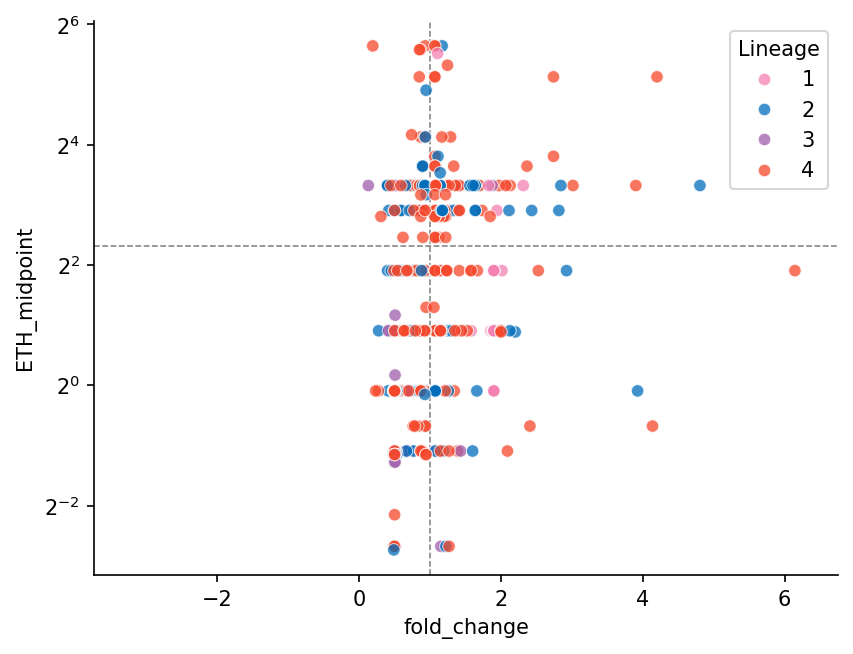

In [6]:
LinToColor_Dict = {"1": "#f381b2",
                   "2": "#006dbb",
                   "3": "#9f5eab",
                   "4": "#f6472b",
                   "5": "#76400e",
                   "6": "#36ba74",
                   "7": "#ffb000",
                   "M.bovis": "gray",
                   "M.canettii": "black",
                   "BOV_AFRI": "gray"
                  }

df_combined['pDST'] = df_combined['Binary'].map({0: 'S', 1: 'R'})

sns.scatterplot(data=df_combined.query("fold_change >= 1.05 | fold_change <= 0.95"),
                x='fold_change',
                y=f'{drug}_midpoint',
                hue='Lineage',
                hue_order=['1', '2', '3', '4'],
                palette=LinToColor_Dict,
                alpha=0.75,
                #style='pDST',
                #style_order=['S', 'R'],
                #markers={'R': 'X', 'S': 'o'}
               )

# both natural numbers (because MICs), so don't have to consider negatives
min_diff = 1 - df_combined['fold_change'].min()
max_diff = df_combined['fold_change'].max() - 1
bound_diff = np.max([min_diff, max_diff])
plt.xlim((1 - bound_diff) * 0.9, (1 + bound_diff) * 1.1)

plt.axhline(y=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)
plt.axvline(x=1, linestyle='--', linewidth=0.75, color='gray', zorder=0)

plt.yscale('log', base=2)
sns.despine()
plt.show()

In [91]:
df_combined.groupby('Lineage')['fold_change'].mean()

Lineage
1             0.981459
2             1.206807
3             0.513165
4             1.468008
6,BOV_AFRI    1.188144
BOV_AFRI      0.649006
Name: fold_change, dtype: float64

In [100]:
len(df_discrepant), len(df_discrepant.query("essential_disagree==0 & essential_disagree_lineage==0")), len(df_combined)

(20, 12, 1842)

In [94]:
df_discrepant.Binary.value_counts(dropna=False)

Binary
0.0    15
1.0     5
Name: count, dtype: int64

In [103]:
df_discrepant.query("essential_disagree != 0 and essential_disagree_lineage != 0")

,Isolate,y_pred_exp,lower,upper,y_test,error,essential_disagree,y_pred_exp_lineage,error_lineage,essential_disagree_lineage,Coll2014,Lineage,Binary,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,fold_change,log_fold_change,fold_change_plot,log_fold_change_plot
1,SAMEA1101749,0.504059,0.00,0.030,-6.058894,1,1,0.217922,1,1,3,3,0.0,0.00,0.0150,0.030,0.432333,-0.838559,2.313031,0.838559
3,SAMEA1102253,0.590184,0.03,0.060,-4.473931,1,1,0.221307,1,1,3,3,0.0,0.03,0.0450,0.060,0.374979,-0.980886,2.666818,0.980886
14,SAMEA7562940,0.259863,0.06,0.125,-3.434403,1,1,0.536504,1,1,4.8,4,0.0,0.06,0.0925,0.125,2.064563,0.724919,2.064563,0.724919


In [98]:
df_combined.query("essential_disagree != 0 and essential_disagree_lineage != 0 and essential_disagree != essential_disagree_lineage")

,Isolate,y_pred_exp,lower,upper,y_test,error,essential_disagree,y_pred_exp_lineage,error_lineage,essential_disagree_lineage,...,Lineage,Binary,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,fold_change,log_fold_change,fold_change_plot,log_fold_change_plot,pDST


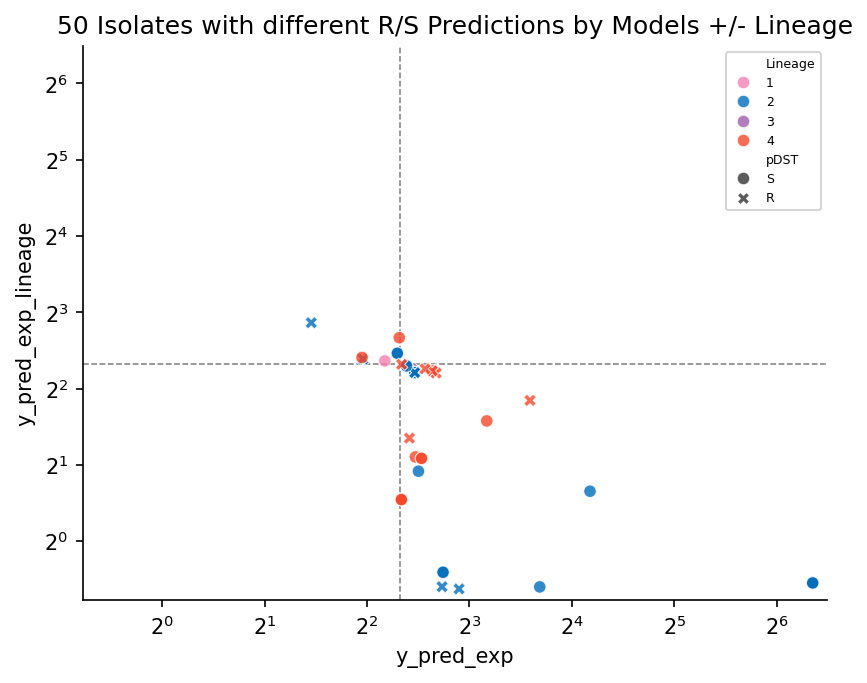

In [342]:
sns.scatterplot(data=df_discrepant,
                x='y_pred_exp',
                y='y_pred_exp_lineage',
                hue='Lineage',
                hue_order=['1', '2', '3', '4'],
                # size='log_fold_change_plot',
                alpha=0.8,
                palette=LinToColor_Dict,
                style='pDST',
                style_order=['S', 'R'],
                markers={'R': 'X', 'S': 'o'}
               )

# both natural numbers (because MICs), so don't have to consider negatives
min_val = df_discrepant[['y_pred_exp', 'y_pred_exp_lineage']].min().min() * 0.9
max_val = df_discrepant[['y_pred_exp', 'y_pred_exp_lineage']].max().max() * 1.1

# 45 degree line
# plt.plot(np.arange(min_val, max_val), np.arange(min_val, max_val), linestyle='--', linewidth=0.75, color='gray', zorder=0)

# critical concentration
plt.axvline(x=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)
plt.axhline(y=cc, linestyle='--', linewidth=0.75, color='gray', zorder=0)

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.title(f"{len(df_discrepant)} Isolates with different R/S Predictions by Models +/- Lineage")

plt.legend(loc='best', fontsize='6')

sns.despine()
plt.show()

In [347]:
df_discrepant.fold_change.min(), df_discrepant.fold_change.max()

(0.008382388190948567, 2.656249933464269)

In [339]:
df_phenos.query("~Lineage.str.contains(',')").groupby("Lineage")[[f"{drug}_midpoint", "Binary"]].mean()

,ETH_midpoint,Binary
Lineage,,
1,3.927495,0.210526
2,3.331335,0.192765
3,1.556303,0.053140
4,3.203958,0.166636


In [290]:
df_phenos.query("category=='test_set'").dropna(subset='Binary').shape

(1073, 19)

In [343]:
search_isolates = df_discrepant.query("Binary == 1").Isolate.values

df_discrepant.query("Binary == 1")[['Isolate', 'lower', 'upper', 'y_pred_exp', 'y_pred_exp_lineage', 'essential_disagree', 'essential_disagree_lineage', 'Lineage', 'Coll2014', 'Binary']]['Coll2014'].value_counts()

Coll2014
2.2.1      7
2.2.2      4
4.2.2      3
3          1
4.1.2.1    1
4.3.2.1    1
4.4.1.1    1
4.7        1
Name: count, dtype: int64

In [344]:
search_isolates = df_discrepant.query("Binary == 0").Isolate.values

df_discrepant.query("Binary == 0")[['Isolate', 'lower', 'upper', 'y_pred_exp', 'y_pred_exp_lineage', 'essential_disagree', 'essential_disagree_lineage', 'Lineage', 'Coll2014', 'Binary']]['Coll2014'].value_counts()

Coll2014
2.2.1      12
4.1.2.1     7
2.2.2       6
2.2.1.1     1
3           1
4.2.2       1
4.3.2.1     1
4.2.2.1     1
1.2.1       1
Name: count, dtype: int64

In [277]:
search_variant = 'inhA_c.-770T>C'

isolates_with_var = isolate_variants.query("variant == @search_variant & ROLLINGDB_ID in @df_phenos.ROLLINGDB_ID").ROLLINGDB_ID.unique()
len(isolates_with_var)

152

In [278]:
df_phenos.query("ROLLINGDB_ID in @isolates_with_var")[['Coll2014']].value_counts().head(10)

Coll2014
2.2.1       119
2.2.1.1       6
4.3.3         5
1.1.2         4
4.1.2.1       4
3             3
4.1           3
1.1.1         1
1.2.1         1
1.2.2         1
Name: count, dtype: int64

In [279]:
119/152

0.7828947368421053

# Microvariants for FQs, Bedaquiline

In [8]:
df_MXF = pd.read_csv(os.path.join(data_dir, "MXF", "data_for_model.csv"))
MXF_pred = pd.read_csv(os.path.join(results_dir, "MXF_lineage_amino_acid", "test_predictions.csv"))
MXF_pred["y_pred_exp"] = np.exp2(MXF_pred["y_pred"])

# MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF", "isolate_variants_fixed_annot.csv"))
# MXF_isolate_variants["AF"] = MXF_isolate_variants["AF"].replace('.', 0.76).astype(float)

# LEV_pred = pd.read_csv(os.path.join(results_dir, "LEV_lineage_amino_acid", "test_predictions.csv"))
# LEV_pred["y_pred_exp"] = np.exp2(LEV_pred["y_pred"])

# LEV_isolate_variants = pd.read_csv(os.path.join(data_path, "LEV", "isolate_variants_fixed_annot.csv"))
# LEV_isolate_variants["AF"] = LEV_isolate_variants["AF"].replace('.', 0.76).astype(float)

In [14]:
isolate_variants.query("ROLLINGDB_ID in @MXF_pred.Isolate & AF > 0.25 & AF <= 0.74 & POS >= 4998 & POS <= 9818").drop_duplicates(['ROLLINGDB_ID', 'variant']).sort_values("POS")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
368117,5748,C,T,Amb,5865.0,False,0.61,267.0,39.0,60.0,0.0,0.0,missense_variant,gyrB,c.509C>T,p.Thr170Met,gyrB_p.Thr170Met,NaN,NaN,SAMEA7544066
423259,6575,C,G,Amb,8003.0,False,0.47,246.0,36.0,60.0,0.0,0.0,missense_variant,gyrB,c.1336C>G,p.Arg446Gly,gyrB_p.Arg446Gly,Levofloxacin,3) Uncertain significance,SAMEA7546245
55853,6579,C,T,Amb,2240.0,False,0.64,152.0,34.0,59.0,0.0,0.0,missense_variant,gyrB,c.1340C>T,p.Ser447Phe,gyrB_p.Ser447Phe,Levofloxacin,2) Assoc w R - Interim,TRL0114463
190719,6620,G,A,Amb,75.0,False,0.27,33.0,36.0,60.0,0.0,0.0,missense_variant,gyrB,c.1381G>A,p.Asp461Asn,gyrB_p.Asp461Asn,Levofloxacin,1) Assoc w R,SAMEA1103121
172960,7161,C,A,Del;Amb,12.0,False,0.68,2.0,315.0,3.0,0.0,27.0,missense_variant,gyrB,c.1922C>A,p.Ala641Asp,gyrB_p.Ala641Asp,Levofloxacin,3) Uncertain significance,SAMEA1101608
640618,7566,G,A,Amb,3573.0,False,0.44,129.0,36.0,60.0,0.0,0.0,missense_variant,gyrA,c.265G>A,p.Asp89Asn,gyrA_p.Asp89Asn,Levofloxacin,1) Assoc w R,SAMEA8718844
118279,7570,C,T,Amb,7446.0,False,0.44,257.0,39.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMN05916382
382254,7570,C,T,Amb,4338.0,False,0.67,363.0,39.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA7544377
177739,7570,C,T,Amb,1171.0,False,0.57,47.0,34.0,59.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA1101749
285370,7570,C,T,Amb,4248.0,False,0.54,143.0,35.0,60.0,0.0,0.0,missense_variant,gyrA,c.269C>T,p.Ala90Val,gyrA_p.Ala90Val,Levofloxacin,1) Assoc w R,SAMEA7525873


# Ethionamide: ethA LoF not always predicted to cause R, so look at mshA. Does it activate ETO, leading to S?

## mshA-mediated ethA-independent ETO activation may be possible

Hypothesis: If mshA is still functional, then mshA may activate ETO, lessential_disagreeding to ETO-S in the presence of ethA LoF mutations. Because we don't know how any mutations affect mshA, look at the prevalence of any non-silent mutations in mshA and see if they co-occur with ethA LoF mutations.

There are 6 missense mshA mutations in the catalog that are Groups 4-5

Codons 76 and 243 have large significant saliency scores

In [15]:
# remove the isolates whose MICs span the CC
df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv"))

In [16]:
df_ETO_phenos.ROLLINGDB_ID.nunique(), isolate_variants.query("ROLLINGDB_ID in @df_ETO_phenos.ROLLINGDB_ID").ROLLINGDB_ID.nunique()

(10435, 10433)

In [19]:
# sample_dirs = pd.read_csv("all_dirs.tsv", sep='\t', header=None)[0].values
# len(sample_dirs)

In [20]:
# isolate_variants_combined = []

# for i, dir_name in enumerate(sample_dirs):

#     sample_id = os.path.basename(dir_name)

#     if os.path.isfile(f"{dir_name}/WHO_resistance/{sample_id}_variants_annot.tsv"):
        
#         df_variants = pd.read_csv(f"{dir_name}/WHO_resistance/{sample_id}_variants_annot.tsv", sep='\t')
#         df_variants['ROLLINGDB_ID'] = sample_id
        
#         isolate_variants_combined.append(df_variants)

#     else:
#         print(f"No {sample_id}")
    
#     if i % 1000 == 0:
#         print(i)

# isolate_variants_combined = pd.concat(isolate_variants_combined)

In [21]:
def lof_present_mutations(gene, include_frameshift=False):

    if include_frameshift:
        lof_lst = ['start_lost', 'stop_gained', 'ablation', 'frameshift_variant']
    else:
        lof_lst = ['start_lost', 'stop_gained', 'ablation']

    # get all variants in the gene of interest
    gene_df = isolate_variants.query("GENE == @gene")

    # these fields are NaN for structural variants and many indels, so set them to pass the thresholds
    gene_df['AF'] = gene_df['AF'].fillna(0.76)
    gene_df['DP'] = gene_df['DP'].fillna(5)
    gene_df['IC'] = gene_df['IC'].fillna(5)
    gene_df['DC'] = gene_df['DC'].fillna(5)
    gene_df['MQ'] = gene_df['MQ'].fillna(30)
    gene_df['BQ'] = gene_df['BQ'].fillna(20)
    gene_df['QUAL'] = gene_df['QUAL'].fillna(10)

    # deletions
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() > gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['AF'] > 0.25) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['MQ'] >= 30) & 
                (gene_df['DC'] >= 5), 
    f'{gene}_LoF'] = 1

    # insertions
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() < gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['AF'] > 0.25) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['MQ'] >= 30) & 
                (gene_df['IC'] >= 5), 
    f'{gene}_LoF'] = 1

    # SNPs/MNPs
    gene_df.loc[((gene_df['EFFECT'].str.contains('|'.join(lof_lst))) | (gene_df['variant'].str.contains('deletion'))) &
                (gene_df['REF'].str.len() == gene_df['ALT'].str.len()) & 
                (~gene_df['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                (gene_df['QUAL'] >= 10) & 
                (gene_df['AF'] > 0.75) & 
                (gene_df['DP'] >= 5) & 
                (gene_df['BQ'] >= 20) & 
                (gene_df['MQ'] >= 30), 
    f'{gene}_LoF'] = 1

    gene_df[f"{gene}_LoF"] = gene_df[f"{gene}_LoF"].fillna(0).astype(int)

    return gene_df

In [36]:
# no frameshift
ethA_annot = lof_present_mutations('ethA', include_frameshift=True)
mshA_annot = lof_present_mutations('mshA', include_frameshift=True)
# Rv0565c_annot = lof_present_mutations('Rv0565c', include_frameshift=True)
# Rv3083_annot = lof_present_mutations('Rv3083', include_frameshift=True)

df_ETO_phenos = pd.read_csv(os.path.join(data_dir, "ETH", "data_for_model.csv")).query("Span_CC==0")
assert sum(pd.isnull(df_ETO_phenos['Binary'])) == 0

for df in [ethA_annot, mshA_annot]:#, Rv0565c_annot, Rv3083_annot]:

    col_name = df.columns[df.columns.str.contains('LoF')][0]
    
    df_ETO_phenos = df_ETO_phenos.merge(df.sort_values(['ROLLINGDB_ID', col_name], ascending=[True, False])[['ROLLINGDB_ID', col_name]].drop_duplicates(['ROLLINGDB_ID'], keep='first'), on='ROLLINGDB_ID', how='left')

    df_ETO_phenos[col_name] = df_ETO_phenos[col_name].fillna(0).astype(int)

    print(f"{sum(df_ETO_phenos[col_name])} isolates have {col_name.split('_')[0]} LoF mutations")

954 isolates have ethA LoF mutations
30 isolates have mshA LoF mutations


In [37]:
mshA_annot.query("EFFECT=='stop_gained' & variant != 'stop_gained'").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,mshA_LoF,ETH_lower_bound,ETH_upper_bound
0,576633,C,A,PASS,4630.0,False,1.0,132.0,35.0,60.0,...,mshA,c.1286C>A,p.Ser429*,mshA_p.Ser429*,Ethionamide,3) Uncertain significance,SAMEA5282343,1,0.0000,1.250
1,576278,G,T,PASS,2491.0,False,1.0,71.0,35.0,60.0,...,mshA,c.931G>T,p.Gly311*,mshA_p.Gly311*,Ethionamide,3) Uncertain significance,SAMEA7526397,1,10.0000,inf
2,576729,C,A,PASS,3051.0,False,1.0,82.0,38.0,60.0,...,mshA,c.1382C>A,p.Ser461*,mshA_p.Ser461*,Ethionamide,3) Uncertain significance,SAMEA7541537,1,0.3125,0.625


In [40]:
mshA_annot.query("EFFECT not in ['missense_variant', 'stop_gained', 'frameshift_variant'] & EFFECT not in @silent_lst").drop_duplicates(['ROLLINGDB_ID', 'variant']).merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound']])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,mshA_LoF,ETH_lower_bound,ETH_upper_bound
0,576274,G,GACGGACTGGTCTGGCTTCACC,PASS,0.0,False,0.76,5.0,20.0,30.0,...,mshA,c.927_928insACGGACTGGTCTGGCTTCACC,p.Pro309_Asp310insThrAspTrpSerGlyPheThr,mshA_p.Pro309_Asp310insThrAspTrpSerGlyPheThr,NaN,NaN,SAMN02360618,0,0.6,1.2
1,576636,G,GGGA,PASS,2876.0,False,0.74,73.0,39.0,60.0,...,mshA,c.1291_1293dupGAG,p.Glu431dup,mshA_p.Glu431dup,NaN,NaN,SAMN05916390,0,5.0,6.0
2,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,60.0,...,mshA,c.669_677delAGTGATTTC,p.Val224_Ser226del,mshA_p.Val224_Ser226del,Ethionamide,3) Uncertain significance,SAMN06094080,0,6.0,8.0
3,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,0.76,5.0,20.0,30.0,...,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,SAMEA1101660,1,10.0,inf
4,576058,GGTCCATCCCGGTGTCGATCTGGACGTGTTCCGCCCGGGTGATCGG...,GTGCCTTCAGCGGCTGGATGCGTCCGACGAAGGCCACCACGCGCTC...,PASS,0.0,False,0.76,5.0,20.0,30.0,...,mshA,c.712_836delGTCCATCCCGGTGTCGATCTGGACGTGTTCCGCC...,p.Val238fs,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,SAMEA1101792,1,10.0,inf
5,576782,G,GGC,PASS,2932.0,False,1.00,84.0,35.0,60.0,...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,SAMEA7563230,1,10.0,inf
6,576782,G,GGC,PASS,2731.0,False,0.71,79.0,35.0,60.0,...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,SAMEA7563256,1,10.0,inf
7,576782,G,GGC,PASS,2998.0,False,0.90,87.0,35.0,60.0,...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,SAMEA7563257,1,5.0,10.0


In [50]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA1101660' & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
174101,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,SAMEA1101660
174108,657081,C,T,PASS,1494.0,False,1.0,41.0,36.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMEA1101660


In [55]:
who_variants.query("variant=='mshA_deletion'")[['Present_R', 'Present_S', 'drug']]

,Present_R,Present_S,drug
17784,1.0,0.0,Ethionamide
23092,2.0,0.0,Isoniazid


In [41]:
len(df_ETO_phenos.query("ethA_LoF==1")), len(df_ETO_phenos.query("ethA_LoF==1 & Binary==0"))

(954, 510)

In [44]:
genes_lst = ['ethA', 'mshA']

ETO_LoF_summary = pd.DataFrame(df_ETO_phenos[[f"{gene}_LoF" for gene in genes_lst]].value_counts()).reset_index()

ETO_LoF_summary_MIC = df_ETO_phenos.groupby([f"{gene}_LoF" for gene in genes_lst])[['Binary', 'ETH_midpoint']].mean().reset_index()

ETO_LoF_summary = ETO_LoF_summary.merge(ETO_LoF_summary_MIC, on=[f"{gene}_LoF" for gene in genes_lst])

ETO_LoF_summary['total_LoF'] = ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]].sum(axis=1)

ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]] = ETO_LoF_summary[[f"{gene}_LoF" for gene in genes_lst]].replace(0, '').replace(1, '+')

ETO_LoF_summary = ETO_LoF_summary.sort_values('total_LoF')
del ETO_LoF_summary['total_LoF']

In [45]:
ETO_LoF_summary

,ethA_LoF,mshA_LoF,count,Binary,ETH_midpoint
0,,,9392,0.138629,2.671361
1,+,,952,0.465336,6.859623
2,,+,28,0.500000,5.435268
3,+,+,2,0.500000,5.450000


In [48]:
df_ETO_phenos.query("mshA_LoF==1").Lineage.value_counts()

Lineage
4    16
3    10
2     4
Name: count, dtype: int64

In [46]:
df_ETO_phenos.query("ethA_LoF==1 & mshA_LoF==1")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF
911,SAMEA5569690,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.002927,4.3.4.2,...,lam,NaN,4.3/LAM,4,0,1.0,4-1,train_set,1,1
8987,SAMN02360618,7H10,0.6,0.9,1.2,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009341,2.2.1,...,"beijing,east_african_indian,mungi",lin2.2.1,NaN,2,0,0.0,2-0,train_set,1,1


In [59]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA5569690' & (drug=='Ethionamide' | GENE=='mshA')").drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
198950,575655,T,TGG,PASS,4870.0,False,0.9,125.0,39.0,60.0,112.0,0.0,frameshift_variant,mshA,c.309_310dupGG,p.Ala104fs,mshA_p.Ala104fs,Ethionamide,3) Uncertain significance,SAMEA5569690
198971,4327132,GT,G,PASS,0.0,False,1.0,126.0,0.0,60.0,0.0,126.0,frameshift_variant,ethA,c.341delA,p.Asn114fs,ethA_p.Asn114fs,Ethionamide,2) Assoc w R - Interim,SAMEA5569690


In [57]:
isolate_variants.query("ROLLINGDB_ID=='SAMN02360618' & (drug=='Ethionamide' | GENE=='mshA')")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
105680,576273,CG,C,PASS,0.0,False,0.78,186.0,37.0,53.0,0.0,145.0,frameshift_variant,mshA,c.928delG,p.Asp310fs,mshA_p.Asp310fs,NaN,NaN,SAMN02360618
105681,576274,G,GACGGACTGGTCTGGCTTCACC,PASS,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,conservative_inframe_insertion,mshA,c.927_928insACGGACTGGTCTGGCTTCACC,p.Pro309_Asp310insThrAspTrpSerGlyPheThr,mshA_p.Pro309_Asp310insThrAspTrpSerGlyPheThr,NaN,NaN,SAMN02360618
105682,657081,C,T,PASS,4224.0,False,1.00,131.0,32.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMN02360618
105683,657142,C,T,PASS,4221.0,False,1.00,126.0,34.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,SAMN02360618
105717,4327404,G,A,PASS,4793.0,False,1.00,143.0,34.0,60.0,0.0,0.0,stop_gained,ethA,c.70C>T,p.Gln24*,ethA_p.Gln24*,Ethionamide,2) Assoc w R - Interim,SAMN02360618


In [11]:
len(df_ETO_phenos.query("ethA_LoF==0 & mshA_LoF==1")), df_ETO_phenos.query("ethA_LoF==0 & mshA_LoF==1").ETH_midpoint.mean()

(28, 5.435267857142857)

In [12]:
ETH_isolates_annotated = df_ETO_phenos.merge(isolate_variants, on='ROLLINGDB_ID', how='left').drop_duplicates(['ROLLINGDB_ID', 'variant'])

isolates_with_group1_2_variants = ETH_isolates_annotated.query("drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").ROLLINGDB_ID.unique()

print(f"{len(isolates_with_group1_2_variants)}/{ETH_isolates_annotated.ROLLINGDB_ID.nunique()} isolates have Group 1-2 ethionamide resistance mutations")

ETH_isolates_no_Group12 =  ETH_isolates_annotated.query("ROLLINGDB_ID not in @isolates_with_group1_2_variants")

2502/10374 isolates have Group 1-2 ethionamide resistance mutations


In [21]:
ethA_nonsense = ETH_isolates_annotated.query("EFFECT=='stop_gained' & variant != 'stop_gained' & GENE=='ethA'")
ethA_nonsense['codon'] = ethA_nonsense['variant'].apply(get_variant_number, args=('+'))

In [36]:
ethA_nonsense.ROLLINGDB_ID.nunique()

193

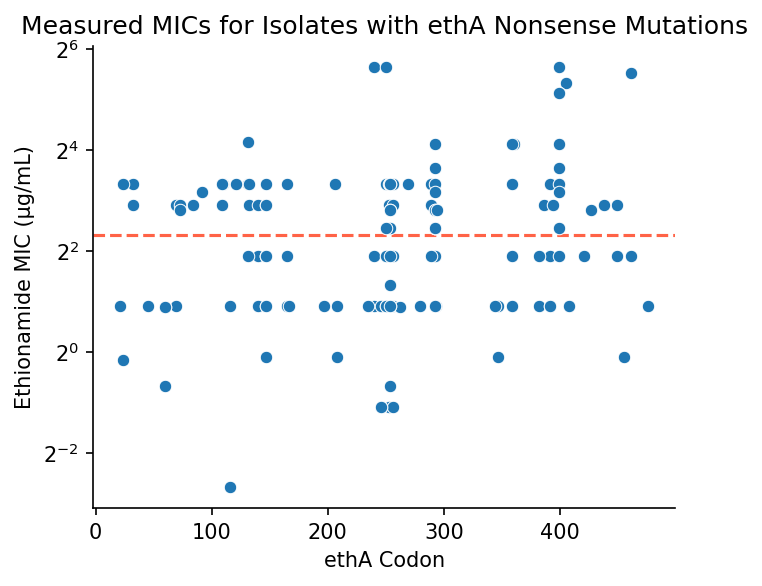

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.scatterplot(data=ethA_nonsense,
                x='codon',
                y='ETH_midpoint'
               )

plt.axhline(y=5, label='CC = 5 µg/mL', linestyle='--', color='tomato', zorder=0)

plt.xlabel('ethA Codon')
plt.ylabel('Ethionamide MIC (µg/mL)')
plt.title('Measured MICs for Isolates with ethA Nonsense Mutations')

plt.yscale('log', base=2)
sns.despine()
plt.savefig("./results/Ethionamide/ethA_nonsense_measured_MICs.svg")

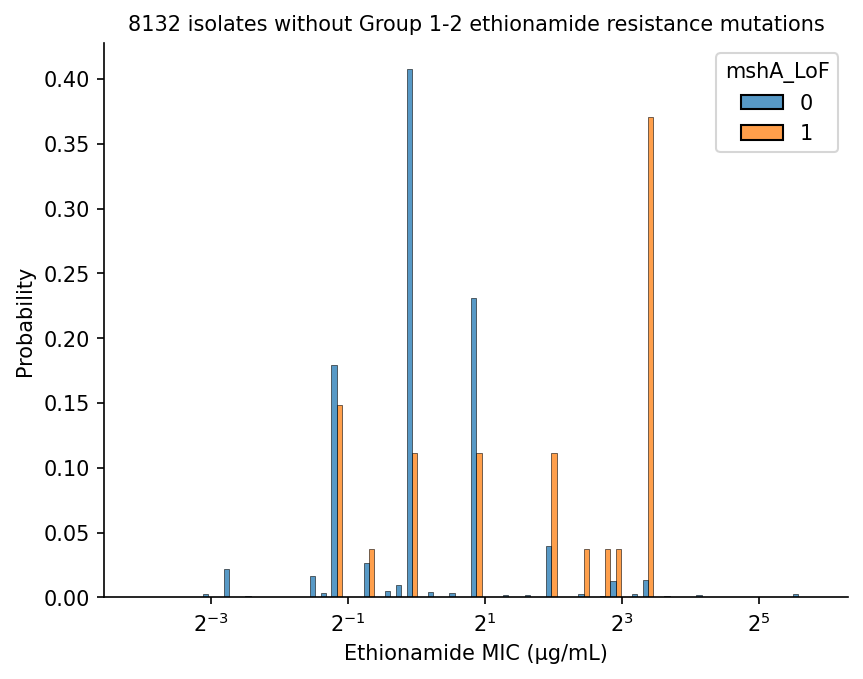

In [45]:
sns.histplot(data=ETH_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID'),
             x='ETH_midpoint',
             hue='mshA_LoF',
             log_scale=2,
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

plt.xlabel('Ethionamide MIC (µg/mL)')
plt.title(f"{ETH_isolates_no_Group12.ROLLINGDB_ID.nunique()} isolates without Group 1-2 ethionamide resistance mutations", fontsize=10)

sns.despine()
plt.show()

In [78]:
ETH_isolates_no_Group12.drop_duplicates('ROLLINGDB_ID').mshA_LoF.value_counts()

mshA_LoF
0    8105
1      27
Name: count, dtype: int64

In [ ]:
df_insilico_pred = pd.concat([pd.read_csv(fName) for fName in glob.glob(os.path.join(results_dir, "ETH_lineage_amino_acid", "inSilico_analysis", "*", "test_predictions.csv"))]).drop_duplicates('ROLLINGDB_ID').reset_index(drop=True)

In [76]:
ETH_isolates_no_Group12.query("mshA_LoF==0 & ETH_midpoint > 5 & drug=='Ethionamide'").merge(df_insilico_pred.rename(columns={'ROLLINGDB_ID': 'variant'}), how='left').sort_values("pred_MIC", ascending=False)[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_upper_bound', 'variant', 'confidence', 'pred_MIC']].head(20)

,ROLLINGDB_ID,ETH_lower_bound,ETH_upper_bound,variant,confidence,pred_MIC
254,SAMEA7546910,10.0,inf,ethA_p.Leu136Arg,3) Uncertain significance,8.190876
160,SAMEA7541809,10.0,inf,ethA_p.Gly343Arg,3) Uncertain significance,7.189657
669,SAMN06010256,50.0,inf,ethA_p.Thr392Arg,3) Uncertain significance,6.055605
248,SAMEA7546677,5.0,10.0,ethA_p.Thr392Arg,3) Uncertain significance,6.055605
352,SAMEA7563261,10.0,inf,ethA_p.Arg479Pro,3) Uncertain significance,6.050108
348,SAMEA7563242,10.0,inf,ethA_p.Arg479Pro,3) Uncertain significance,6.050108
16,SAMEA1102553,10.0,inf,ethA_p.Asp56Ala,3) Uncertain significance,5.538521
25,SAMEA5569696,5.0,10.0,ethA_p.Asp56Ala,3) Uncertain significance,5.538521
461,SAMEA8741532,10.0,inf,ethA_p.Cys294Phe,3) Uncertain significance,5.518435
515,SAMEA8741770,10.0,inf,ethA_p.Cys294Phe,3) Uncertain significance,5.518435


In [74]:
ETH_isolates_no_Group12.query("mshA_LoF==0 & ETH_midpoint > 5 & drug=='Ethionamide'").merge(df_insilico_pred.rename(columns={'ROLLINGDB_ID': 'variant'}), how='left').query("ROLLINGDB_ID=='SAMEA5282384'")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,log2_pred_MIC,pred_MIC
774,SAMEA5282384,NaN,47.87712,47.87712,inf,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011605,4.3.3,...,0.0,missense_variant,Rv3083,c.1351A>G,p.Met451Val,Rv3083_p.Met451Val,Ethionamide,3) Uncertain significance,NaN,NaN


In [71]:
ETH_isolates_no_Group12.query("mshA_LoF==0 & ETH_midpoint > 5 & drug=='Ethionamide'").variant.value_counts()

variant
Rv0565c_c.390G>A       114
Rv0565c_p.Arg110His    101
Rv0565c_p.Ser68Pro      97
mshA_p.Ala187Val        81
ethA_c.171C>T           42
                      ... 
Rv3083_p.Trp45Leu        1
Rv3083_p.Gly354Ser       1
ethA_p.Gly43Ala          1
Rv3083_p.Arg446Pro       1
Rv3083_p.Met451Val       1
Name: count, Length: 182, dtype: int64

In [10]:
529/985

0.5370558375634518

In [12]:
df_ETO_phenos.query("ethA_LoF==1").ETH_midpoint.mean()

7.087447746192893

In [25]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA5282463' & drug=='Ethionamide'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
100160,657081,C,T,PASS,1666.0,False,0.99,49.0,36.0,60.0,0.0,0.0,synonymous_variant,Rv0565c,c.390G>A,p.Val130Val,Rv0565c_c.390G>A,Ethionamide,4) Not assoc w R - Interim,SAMEA5282463
100161,657142,C,T,PASS,2200.0,False,1.00,60.0,37.0,60.0,0.0,0.0,missense_variant,Rv0565c,c.329G>A,p.Arg110His,Rv0565c_p.Arg110His,Ethionamide,3) Uncertain significance,SAMEA5282463
100198,4327294,G,T,PASS,3407.0,False,1.00,100.0,35.0,59.0,0.0,0.0,stop_gained,ethA,c.180C>A,p.Tyr60*,ethA_p.Tyr60*,Ethionamide,2) Assoc w R - Interim,SAMEA5282463


In [24]:
df_ETO_phenos.query("ethA_LoF==1").sort_values("ETH_lower_bound")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
8916,SAMEA5282463,7H10,0.0000,0.62500,1.2500,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014009,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,1,0,0
9976,JPN-R2012-0033,7H10,0.0000,0.12500,0.2500,MGIT,JATA-KIT,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.016002,2.2.1,...,"lin2.2.1,asian_african_3",NaN,2,0,0.0,2-0,train_set,1,0,0
9474,SAMN05918740,7H10,0.0000,0.62500,1.2500,7H10,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.014279,4.1.2.1,...,NaN,4.1.2/Haarlem,4,0,0.0,4-0,train_set,1,0,0
4963,SAMEA7555799,7H10,0.0000,0.15625,0.3125,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.013125,2.2.1,...,"lin2.2.1,asia_ancestral_2",NaN,2,0,0.0,2-0,train_set,1,0,0
4711,SAMEA7546912,7H10,0.3125,0.46875,0.6250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012136,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8986,SAMN02360617,7H10,40.0000,40.00000,inf,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.008219,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,1.0,2-1,train_set,1,0,1
10178,KOR-K2016-0145,7H10,48.0000,56.00000,64.0000,MGIT,JATA-KIT,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013231,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,1.0,2-1,test_set,1,0,0
9940,SAMN06094110,7H10,50.0000,50.00000,inf,7H10,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.004158,4.3.4.2,...,NaN,4.3/LAM,4,0,1.0,4-1,train_set,1,0,0
9742,SAMN06010231,7H10,50.0000,50.00000,inf,7H10,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.005318,4.1.2.1,...,NaN,4.1.2/Haarlem,4,0,1.0,4-1,test_set,1,0,0


In [51]:
# - frameshift, + frameshift
187/337, 529/985

(0.5548961424332344, 0.5370558375634518)

In [5]:
df_ETO_phenos.query("mshA_LoF==1").shape

(30, 22)

In [8]:
mshA_LoF.EFFECT.unique()

array(['missense_variant', 'synonymous_variant', 'frameshift_variant',
       'stop_gained', 'conservative_inframe_insertion',
       'disruptive_inframe_deletion', 'transcript_ablation',
       'frameshift_variant&stop_gained',
       'frameshift_variant&stop_lost&splice_region_variant'], dtype=object)

In [33]:
search_lst = mshA_LoF.query("EFFECT.str.contains('frameshift') & GENE=='mshA' & ROLLINGDB_ID in @df_ETO_phenos.ROLLINGDB_ID").ROLLINGDB_ID.unique()

len(search_lst)

27

In [26]:
mshA_LoF.query("EFFECT.str.contains('ablation') & GENE=='mshA'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,mshA_LoF
174101,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,0.76,5.0,20.0,30.0,...,5.0,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,SAMEA1101660,1
174102,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,0.76,5.0,20.0,30.0,...,5.0,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Isoniazid,3) Uncertain significance,SAMEA1101660,1


In [17]:
mshA_LoF.query("EFFECT == 'stop_gained' & GENE=='mshA' & variant != 'stop_gained'").ROLLINGDB_ID.nunique(), mshA_LoF.query("EFFECT == 'stop_gained' & GENE=='mshA' & variant != 'stop_gained'").variant.nunique()

(4, 4)

In [19]:
mshA_LoF.query("EFFECT == 'stop_gained' & GENE=='mshA' & variant != 'stop_gained'").drop_duplicates(['ROLLINGDB_ID', 'variant'])

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,mshA_LoF
82687,575511,C,A,PASS,2152.0,False,1.0,61.0,35.0,60.0,...,0.0,stop_gained,mshA,c.164C>A,p.Ser55*,mshA_p.Ser55*,Isoniazid,3) Uncertain significance,SAMEA3392629,1
97563,576633,C,A,PASS,4630.0,False,1.0,132.0,35.0,60.0,...,0.0,stop_gained,mshA,c.1286C>A,p.Ser429*,mshA_p.Ser429*,Ethionamide,3) Uncertain significance,SAMEA5282343,1
313313,576278,G,T,PASS,2491.0,False,1.0,71.0,35.0,60.0,...,0.0,stop_gained,mshA,c.931G>T,p.Gly311*,mshA_p.Gly311*,Ethionamide,3) Uncertain significance,SAMEA7526397,1
324432,576729,C,A,PASS,3051.0,False,1.0,82.0,38.0,60.0,...,0.0,stop_gained,mshA,c.1382C>A,p.Ser461*,mshA_p.Ser461*,Ethionamide,3) Uncertain significance,SAMEA7541537,1


In [21]:
df_ETO_phenos.query("ROLLINGDB_ID=='SAMEA3392629'")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF


In [16]:
df_ETO_phenos.query("ROLLINGDB_ID in ['SAMEA7525534', 'SAMEA7525768', 'SAMEA7526160', 'SAMEA7563381']")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
2729,SAMEA7525534,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.015644,2.2.1,...,"lin2.2.1,asia_ancestral_3",NaN,2,0,0.0,2-0,train_set,1,0,0
3184,SAMEA7526160,7H10,2.50,3.750,5.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006935,2.2.1,...,"lin2.2.1,asia_ancestral_3",NaN,2,0,0.0,2-0,train_set,1,0,0
7244,SAMEA7563381,7H10,1.25,1.875,2.5,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.008973,2.2.1,...,"lin2.2.1,asia_ancestral_3",NaN,2,0,0.0,2-0,train_set,1,0,0


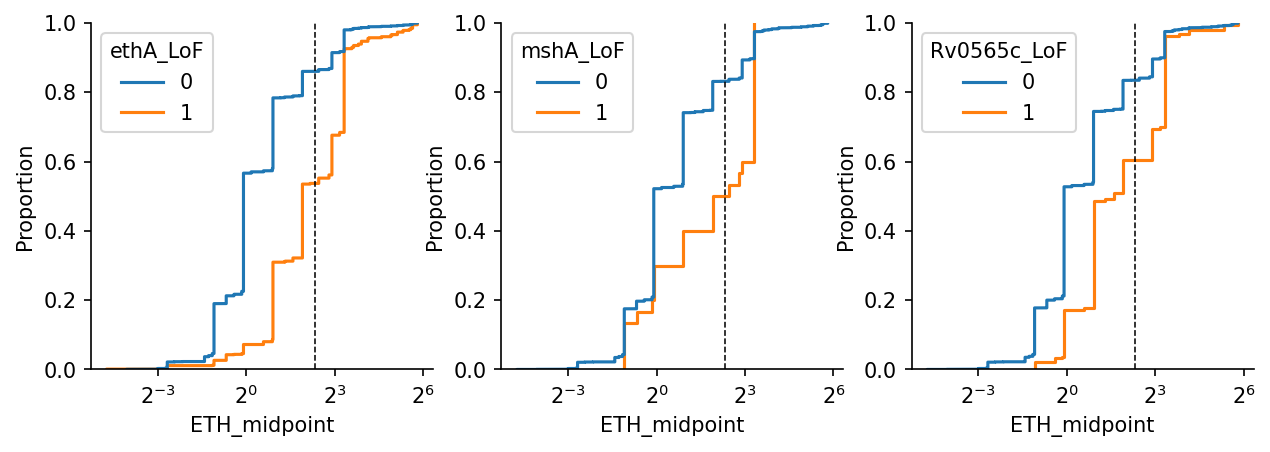

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

sns.ecdfplot(data=df_ETO_phenos,
             x='ETH_midpoint',
             log_scale=2,
             hue='ethA_LoF',
             ax=ax[0]
            )

sns.ecdfplot(data=df_ETO_phenos,
             x='ETH_midpoint',
             log_scale=2,
             hue='mshA_LoF',
             ax=ax[1]
            )

sns.ecdfplot(data=df_ETO_phenos,
             x='ETH_midpoint',
             log_scale=2,
             hue='Rv0565c_LoF',
             ax=ax[2]
            )

ax[0].axvline(5, color='black', linestyle='--', linewidth=0.75)
ax[1].axvline(5, color='black', linestyle='--', linewidth=0.75)
ax[2].axvline(5, color='black', linestyle='--', linewidth=0.75)

sns.despine()
plt.show()

In [194]:
mshA_LoF.merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'EFFECT', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,FILTER,POS,REF,ALT,AF,BQ,MQ,DP,variant,EFFECT,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,category,Binary,Coll2014,Lineage
0,SAMEA3392629,PASS,575511,C,A,1.0,35.0,60.0,61.0,mshA_p.Ser55*,stop_gained,0.0000,5.00000,10.000,test_set,NaN,4,4
1,SAMEA5282343,PASS,576633,C,A,1.0,35.0,60.0,132.0,mshA_p.Ser429*,stop_gained,0.0000,0.62500,1.250,test_set,0.0,4,4
3,SAMEA1101660,PASS,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,NaN,NaN,NaN,NaN,mshA_deletion,transcript_ablation,10.0000,10.00000,inf,train_set,1.0,3,3
5,SAMEA1101792,PASS,576058,GGTCCATCCCGGTGTCGATCTGGACGTGTTCCGCCCGGGTGATCGG...,GTGCCTTCAGCGGCTGGATGCGTCCGACGAAGGCCACCACGCGCTC...,NaN,NaN,NaN,NaN,mshA_p.Val238fs,frameshift_variant&stop_gained,10.0000,10.00000,inf,train_set,1.0,3,3
7,SAMEA7526397,PASS,576278,G,T,1.0,35.0,60.0,71.0,mshA_p.Gly311*,stop_gained,10.0000,10.00000,inf,train_set,1.0,3.1.2,3
9,SAMEA7541537,PASS,576729,C,A,1.0,38.0,60.0,82.0,mshA_p.Ser461*,stop_gained,0.3125,0.46875,0.625,train_set,0.0,2.2.1.1,2


In [200]:
Rv0565c_LoF.merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'EFFECT', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,FILTER,POS,REF,ALT,AF,BQ,MQ,DP,variant,EFFECT,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,category,Binary,Coll2014,Lineage
0,JPN-R2012-0010,PASS,657257,C,A,1.00,35.0,60.0,94.0,Rv0565c_p.Glu72*,stop_gained,4.0000,6.00000,8.000,test_set,NaN,4.5,4
1,KOR-K2016-0229,PASS,656094,C,T,1.00,35.0,59.0,191.0,Rv0565c_p.Trp459*,stop_gained,0.5000,0.75000,1.000,train_set,0.0,4.9,4
2,SAMN02360566,PASS,657108,C,T,0.99,36.0,60.0,112.0,Rv0565c_p.Trp121*,stop_gained,5.0000,7.50000,10.000,validation_set,1.0,2.2.2,2
3,SAMN02360615,PASS,657109,C,T,1.00,37.0,60.0,104.0,Rv0565c_p.Trp121*,stop_gained,2.5000,3.75000,5.000,train_set,0.0,2.2.2,2
4,SAMN05916344,PASS,656674,C,T,0.86,37.0,60.0,265.0,Rv0565c_p.Trp266*,stop_gained,15.0000,17.50000,20.000,train_set,1.0,4.3.3,4
5,SAMEA7524813,PASS,656674,C,T,1.00,35.0,60.0,81.0,Rv0565c_p.Trp266*,stop_gained,10.0000,10.00000,inf,train_set,1.0,1.1.2,1
6,SAMEA7541845,PASS,657033,G,C,1.00,38.0,60.0,101.0,Rv0565c_p.Tyr146*,stop_gained,0.6250,0.93750,1.250,train_set,0.0,4.4.1.1,4
7,SAMEA7544255,PASS,657204,G,T,1.00,38.0,60.0,255.0,Rv0565c_p.Tyr89*,stop_gained,0.3125,0.46875,0.625,train_set,0.0,2.2.1,2
8,SAMEA8741415,PASS,656087,G,A,1.00,39.0,60.0,60.0,Rv0565c_p.Arg462*,stop_gained,2.5000,3.75000,5.000,train_set,0.0,2.2.1,2
9,SAMEA8741575,PASS,656087,G,A,1.00,39.0,60.0,98.0,Rv0565c_p.Arg462*,stop_gained,5.0000,7.50000,10.000,validation_set,1.0,2.2.1,2


In [203]:
h37Rv_genes.query("Symbol=='Rv0565c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
580,580,CDS,656010,657470,-,0.0,Rv0565c,Rv0565c,Function unknown; probably involved in cellula...,Probable monooxygenase,...,O53762,"ML2281,ML2281c",MMAR_0917,MSMEG_2038,Mb0580c,NaN,NaN,NaN,NaN,NaN


In [206]:
(657470-656010+1)/3

487.0

In [185]:
mshA_fs_isolates = mshA_LoF.query("variant.str.contains('fs')").merge(df_phenos, on='ROLLINGDB_ID').dropna(subset='Binary').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

mshA_fs_isolates.ROLLINGDB_ID.nunique(), mshA_fs_isolates.variant.nunique()

(24, 18)

In [174]:
mshA_LoF.query("~variant.str.contains('fs')").merge(df_phenos, on='ROLLINGDB_ID').drop_duplicates(["ROLLINGDB_ID", "variant"])[['ROLLINGDB_ID', 'FILTER', 'POS', 'REF', 'ALT', 'AF', 'BQ', 'MQ', 'DP', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'category', 'Binary', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
230654,SAMN06094080,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,60.0,disruptive_inframe_deletion,mshA,c.669_677delAGTGATTTC,p.Val224_Ser226del,mshA_p.Val224_Ser226del,Ethionamide,3) Uncertain significance,NaN,NaN
230655,SAMN06094080,576015,AAGTGATTTC,A,PASS,0.0,False,0.91,130.0,38.0,60.0,disruptive_inframe_deletion,mshA,c.669_677delAGTGATTTC,p.Val224_Ser226del,mshA_p.Val224_Ser226del,Isoniazid,3) Uncertain significance,NaN,NaN


In [170]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA1101660' & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
269742,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,NaN,NaN
269743,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Isoniazid,3) Uncertain significance,NaN,NaN


In [126]:
mshA_LoF.query("variant.str.contains('ablation')")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2


In [168]:
df_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/cryptic_output/SAMEA1101660/WHO_resistance/SAMEA1101660_variants_annot.tsv", sep='\t')

In [135]:
df_protein_seqs.query("mshA_AA.str.startswith('-')")#['mshA_AA'].values

,category,ROLLINGDB_ID,fabG1_AA,inhA_AA,ethA_AA,ethR_AA,mshA_AA,Rv0565c_AA,ndh_AA,Rv3083_AA
1501,train_set,SAMEA1101660,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MTTSAASQASLPRGRRTARPSGDDRELAILATAENLLEDRPLADIS...,----------------------------------------------...,MSVTPNAGCVDVVIVGAGISGLGAAYRIIERNPQLTYTILERRARI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MNQHFDVLIIGAGLSGIGTACHVTAEFPDKTIALLERRERLGGTWD...
2911,train_set,SAMEA7525795,MTATATEGAKPPFVSRSVLVTGGNRGIGLAIAQRLAADGHKVAVTH...,MTGLLDGKRILVSGIITDSSIAFHIARVAQEQGAQLVLTGFDRLRL...,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MTTSAASQASLPRGRRTARPSGDDRELAILATAENLLEDRPLADIS...,----------------------------------------------...,MSVTPNAGCVDVVIVGAGISGLGAAYRIIERNPQLTYTILERRARI...,MSPQQEPTAQPPRRHRVVIIGSGFGGLNAAKKLKRADVDIKLIART...,MNQHFDVLIIGAGLSGIGTACHVTAEFPDKTIALLERRERLGGTWD...


In [ ]:
bcftools filter -i "POS > 575300 & POS <= 576790" SAMEA1101660.vcf

In [140]:
model_loci.query("Locus=='mshA'")

,Locus,Start,End,Sense
13,mshA,575300,576790,+


In [141]:
isolate_variants.query("ROLLINGDB_ID in ['SAMEA1101660', 'SAMEA7525795'] & POS > 575300 & POS <= 576790")# & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2


In [110]:
len(df_ETO_phenos.query("ethA_LoF==1")), len(df_ETO_phenos.query("ethA_LoF==1 & ETH_upper_bound <= 5"))

(854, 449)

In [111]:
452/858

0.5268065268065268

In [112]:
df_ETO_phenos.query("ethA_LoF==1 & ETH_upper_bound <= 5").Binary.unique()

array([0.])

In [207]:
df_ETO_phenos.groupby(['ethA_LoF', 'mshA_LoF', 'Rv0565c_LoF'])[['ETH_midpoint', 'Binary']].mean().merge(pd.DataFrame(df_ETO_phenos.groupby(['ethA_LoF', 'mshA_LoF', 'Rv0565c_LoF'])['ROLLINGDB_ID'].count()), left_index=True, right_index=True)

ETH_midpoint    Binary  ROLLINGDB_ID
ethA_LoF mshA_LoF Rv0565c_LoF                                      
0        0        0                2.757718  0.138981          9739
                  1                4.582466  0.294118           154
         1        0                4.917500  0.458333            25
                  1               10.000000  1.000000             1
1        0        0                7.163371  0.458629           854
                  1                9.902778  0.851852            27
         1        0                7.100000  0.750000             4

In [39]:
df_ETO_phenos.query("ethA_LoF==0 & (mshA_LoF==1 | Rv0565c_LoF==1)").sort_values('ETH_lower_bound')#['ETH_midpoint'].mean()

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
891,SAMEA5282343,7H10,0.0000,0.62500,1.250,LJ,farhat_internal,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.008116,4,...,NaN,4,4,0,0.0,4-0,test_set,0,1,0
3477,SAMEA7541537,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010707,2.2.1.1,...,"lin2.2.1,pacific_RD150",NaN,2,0,0.0,2-0,train_set,0,1,0
4300,SAMEA7544255,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009528,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,0,0,1
10293,KOR-K2016-0229,7H10,0.5000,0.75000,1.000,MGIT,JATA-KIT,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.010006,4.9,...,NaN,4.10/PGG3,4,0,0.0,4-0,train_set,0,0,1
3686,SAMEA7541845,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.006251,4.4.1.1,...,NaN,4,4,0,0.0,4-0,train_set,0,0,1
8364,SAMEA8741415,7H10,2.5000,3.75000,5.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012225,2.2.1,...,"europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,0.0,2-0,train_set,0,0,1
9154,SAMN02360615,7H10,2.5000,3.75000,5.000,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.007430,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,0.0,2-0,train_set,0,0,1
8471,SAMEA8741575,7H10,5.0000,7.50000,10.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010704,2.2.1,...,"europe/russia_B0/W148_outbreak,lin2.2.1",NaN,2,0,1.0,2-1,validation_set,0,0,1
9127,SAMN02360566,7H10,5.0000,7.50000,10.000,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009017,2.2.2,...,"asia_ancestral_1,lin2.2",NaN,2,0,1.0,2-1,validation_set,0,0,1
1501,SAMEA1101660,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011624,3,...,NaN,NaN,3,0,1.0,3-1,train_set,0,1,0


In [130]:
df_protein_seqs = pd.read_csv(os.path.join(results_dir, "ETH", "df_protein_seqs.csv"))

In [124]:
# verified this using the gene coordinates too
mshA_ref_len = len(df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")['mshA_AA'].values[0].replace('-', ''))
print(mshA_ref_len)

# stop codon lost is found in 3 ETH-resistant isolates
mshA_diff_length = df_protein_seqs.loc[df_protein_seqs['mshA_AA'].str.replace('-', '').str.len() != mshA_ref_len][['ROLLINGDB_ID', 'ethA_AA', 'mshA_AA', 'category']]
mshA_diff_length['mshA_length'] = df_protein_seqs['mshA_AA'].str.replace('-', '').str.len()
print(len(mshA_diff_length))

480
28


In [127]:
sessential_disagreerch_lst = mshA_diff_length.query("mshA_length > @mshA_ref_len").ROLLINGDB_ID.values

In [129]:
# isolate_variants.query("ROLLINGDB_ID in @sessential_disagreerch_lst & GENE=='mshA'")

In [ ]:
isolate_variants.loc[(isolate_variants['GENE']=='inhA') & 
                        (isolate_variants['REF'].str.len() > isolate_variants['ALT'].str.len()) & 
                                 ((isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) |
                                 (isolate_variants['AF'] <= 0.75) | (isolate_variants['DP'] < 5))
                                ]

In [75]:
mshA_diff_length_variants = isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['start_lost', 'stop_gained', 'frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
                                (isolate_variants['ROLLINGDB_ID'].isin(mshA_diff_length['ROLLINGDB_ID']))
                                ].drop_duplicates(['ROLLINGDB_ID', 'variant'])

mshA_diff_length_variants['codon'] = mshA_diff_length_variants['variant'].apply(get_variant_number, args=('+'))

# add MICs
mshA_diff_length_variants = mshA_diff_length_variants.merge(df_ETO_phenos[['ROLLINGDB_ID', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category']])

# add mshA protein lengths
mshA_diff_length_variants = mshA_diff_length_variants.merge(mshA_diff_length[['ROLLINGDB_ID', 'mshA_length']])

In [27]:
isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
(isolate_variants['ROLLINGDB_ID'].isin(df_ETO_phenos.dropna(subset="Binary")['ROLLINGDB_ID'])) & (isolate_variants['variant'].str.contains('fs'))
].ROLLINGDB_ID.nunique()

24

In [28]:
isolate_variants.loc[(isolate_variants['GENE']=='mshA') & 
                                 (isolate_variants['EFFECT'].str.contains('|'.join(['frameshift']))) &
                                 (~isolate_variants['FILTER'].str.contains('|'.join(['Del', 'LowCov']))) &
                                 ~(isolate_variants['AF'] <= 0.75) & 
                                 ~(isolate_variants['DP'] < 5) & 
(isolate_variants['ROLLINGDB_ID'].isin(df_ETO_phenos.dropna(subset="Binary")['ROLLINGDB_ID'])) & (isolate_variants['variant'].str.contains('fs'))
].variant.nunique()

18

In [133]:
who_variants.query("variant=='pncA_p.Arg140fs'")[['Present_SOLO_R', 'Present_SOLO_S']]

,Present_SOLO_R,Present_SOLO_S
35812,6.0,0.0


In [96]:
mshA_diff_length_variants.query("ETH_midpoint > 5 & codon >= 150 & codon <= 350")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
3,SAMN06094112,mshA_p.Leu157fs,Ethionamide,3) Uncertain significance,6.0,7.0,8.0,1.0,train_set,219
4,SAMEA1101792,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,255
10,SAMEA7525944,mshA_p.Thr176fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,validation_set,219
11,SAMEA7526397,mshA_p.Gly311*,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,test_set,310
13,SAMEA7561337,mshA_p.Ala279fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,326
14,SAMEA7561425,mshA_p.Ala279fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,326
17,SAMEA8741200,mshA_p.His175fs,Ethionamide,3) Uncertain significance,10.0,10.0,inf,1.0,train_set,183


In [83]:
mshA_diff_length_variants.query("variant.str.endswith('*')")[['ROLLINGDB_ID', 'variant', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
0,SAMEA3392629,mshA_p.Ser55*,0.0000,5.00000,10.000,NaN,test_set,54
1,SAMEA5282343,mshA_p.Ser429*,0.0000,0.62500,1.250,0.0,train_set,428
11,SAMEA7526397,mshA_p.Gly311*,10.0000,10.00000,inf,1.0,test_set,310
12,SAMEA7541537,mshA_p.Ser461*,0.3125,0.46875,0.625,0.0,train_set,460


This is more of a simulation because essential_disagreerly stop codons are very rare in mshA. There are only 4 observed in this dataset -- at codons 55, 311, 429, and 461. However, the isolates with stop codons at 429 and 461 are ETH-S, and the isolate with a stop codon at 311 is ETH-R. The isolate with a stop codon at 55 has a recorded MIC of (0, 10] and was not tested at a concentration of 5 µg/mL. Frameshift mutations are considerably more common mshA. 

Three isolates with loss of a stop codon in mshA due to the same frameshift on the last codon are all resistant, suggesting a possible association with resistance. All three are L3.1.1 and also share a single variant in ethA -- ethA_p.Asn287_Leu333del, which is of uncertain significance in the 2023 WHO mutation catalog.

In [94]:
df_pred = pd.read_csv(os.path.join(results_dir, "ETH_linessential_disagreege_amino_acid", "test_predictions.csv"))
df_pred.query("Isolate=='SAMessential_disagree3392629'")

,Isolate,y_test,lower,upper,Span_CC,y_pred
1073,SAMEA3392629,2.321928,0.0,10.0,1,3.134888


In [113]:
regression_who_results.query("mutation=='ethA_p.Asn287_Leu333del'")[['WHO_BH_pval', 'ALL_BH_pval']]

,WHO_BH_pval,ALL_BH_pval
9977,0.67482,0.567647


In [65]:
mshA_diff_length_variants.query("mshA_length > 450").sort_values("ETH_lower_bound")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2', 'ETH_lower_bound', 'ETH_midpoint', 'ETH_upper_bound', 'Binary', 'category', 'mshA_length']]

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,Binary,category,mshA_length
5,SAMEA1103157,mshA_p.Ala372fs,Ethionamide,3) Uncertain significance,0.3125,0.46875,0.625,0.0,train_set,481
13,SAMEA7541537,mshA_p.Ser461*,Ethionamide,3) Uncertain significance,0.3125,0.46875,0.625,0.0,train_set,460
20,SAMEA7564184,mshA_p.Gln453fs,NaN,NaN,0.6250,0.93750,1.250,0.0,test_set,482
17,SAMEA7563257,mshA_p.Ter481fs,NaN,NaN,5.0000,7.50000,10.000,1.0,train_set,481
16,SAMEA7563230,mshA_p.Ter481fs,NaN,NaN,10.0000,10.00000,inf,1.0,train_set,481
22,SAMEA8742358,mshA_p.Ala422fs,Ethionamide,3) Uncertain significance,10.0000,10.00000,inf,1.0,train_set,481


In [67]:
isolate_variants.query("variant=='mshA_p.Ter481fs'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877523,SAMEA7563230,576782,G,GGC,PASS,2932.0,False,1.00,84.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN
879489,SAMEA7563256,576782,G,GGC,PASS,2731.0,False,0.71,79.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN
879573,SAMEA7563257,576782,G,GGC,PASS,2998.0,False,0.90,87.0,35.0,60.0,frameshift_variant&stop_lost&splice_region_var...,mshA,c.1439_1440dupCG,p.Ter481fs,mshA_p.Ter481fs,NaN,NaN,NaN,NaN


In [108]:
isolate_variants.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree7563256', 'SAMessential_disagree7563257'] & GENE=='ethA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877576,SAMEA7563230,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
879541,SAMEA7563256,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
879625,SAMEA7563257,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance


In [103]:
df_protein_seqs.query("ROLLINGDB_ID=='SAMessential_disagree7563230'")['mshA_AA'].str.replace('-', '').str.len()

7138    481
Name: mshA_AA, dtype: int64

In [106]:
df_protein_seqs.query("ROLLINGDB_ID=='SAMessential_disagree7563230'")['mshA_AA'].str.replace('-', '').values[0]

'MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRRVALLAVHTSPLAQPGTGDAGGMNVYMLQSALHLARRGIEVEIFTRATASADPPVVRVAPGVLVRNVVAGPFEGLDKYDLPTQLCAFAAGVLRAEAVHEPGYYDIVHSHYWLSGQVGWLARDRWAVPLVHTAHTLAAVKNAALADGDGPEPPLRTVGEQQVVDEADRLIVNTDDEARQVISLHGADPARIDVVHPGVDLDVFRPGDRRAARAALGLPVDERVVAFVGRIQPLKAPDIVLRAAAKLPGVRIIVAGGPSGSGLASPDGLVRLADELGISARVTFLPPQSHTDLATLFRAADLVAVPSYSESFGLVAVEAQACGTPVVAAAVGGLPVAVRDGITGTLVSGHEVGQWADAIDHLLRLCAGPRGRVMSRAAARHAATFSWENTTDALLASYRRAIGEYNAERQRRGGEVISDLVAVGKPRHWTPRRGVGAR'

In [70]:
df_ETO_phenos.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree7563256', 'SAMessential_disagree7563257']")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
7138,SAMEA7563230,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009661,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1
7156,SAMEA7563256,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010240,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,0
7157,SAMEA7563257,7H10,5.0,7.5,10.0,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010986,3.1.1,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1


In [63]:
isolate_variants.query("ROLLINGDB_ID in ['SAMessential_disagree7563230', 'SAMessential_disagree8742358'] & GENE=='ethA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V1,confidence_V1,drug_V2,confidence_V2
877576,SAMEA7563230,4326474,GCAGTTCGCGACCTGAGTTCAGCCGGATTCCGGTCGCGGTGAACCG...,G,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_deletion,ethA,c.859_999del,p.Asn287_Leu333del,ethA_p.Asn287_Leu333del,NaN,NaN,Ethionamide,3) Uncertain significance
1085382,SAMEA8742358,4326992,A,C,PASS,4187.0,False,1.0,113.0,37.0,60.0,missense_variant,ethA,c.482T>G,p.Ile161Ser,ethA_p.Ile161Ser,Ethionamide,3) Uncertain significance,Ethionamide,3) Uncertain significance


In [478]:
df_ETO_phenos.query("ethA_LoF == 1 & mshA_LoF == 1")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
1888,SAMEA5569690,7H10,10.0,10.0,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.002927,4.3.4.2,...,lam,NaN,4.3/LAM,0,1.0,4,4-1,train_set,1,1
9171,SAMN02360618,7H10,0.6,0.9,1.2,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009341,2.2.1,...,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set,1,1


In [484]:
df_ETO_phenos.query("ethA_LoF == 0 & mshA_LoF == 1")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category,ethA_LoF,mshA_LoF
247,SAMEA7526397,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.008058,3.1.2,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,test_set,0,1
729,SAMEA7564184,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011422,2.2.1,...,"beijing,mungi","asian_african_1,lin2.2.1",NaN,0,0.0,2,2-0,test_set,0,1
1564,SAMEA1101792,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010370,3,...,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set,0,1
1727,SAMEA1103157,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.016592,3,...,"east_african_indian,tur,ghana,mungi",NaN,NaN,0,0.0,3,3-0,train_set,0,1
1847,SAMEA5569642,7H10,1.2500,1.87500,2.500,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012280,4,...,canetti,NaN,4,0,0.0,4,4-0,validation_set,0,1
2189,SAMEA5570058,7H10,2.5000,3.75000,5.000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.011326,4,...,canetti,NaN,4,0,0.0,4,4-0,train_set,0,1
2307,SAMEA7524880,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010895,2.2.1,...,"beijing,mungi,canetti","lin2.2.1,asian_african_2",NaN,0,1.0,2,2-1,train_set,0,1
2548,SAMEA7525236,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012682,3,...,"east_african_indian,mungi",NaN,NaN,0,0.0,3,3-0,train_set,0,1
2551,SAMEA7525241,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.014796,3,...,east_african_indian,NaN,NaN,0,0.0,3,3-0,train_set,0,1
2635,SAMEA7525363,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.012914,4.5,...,canetti,NaN,4.5,0,0.0,4,4-0,train_set,0,1


In [26]:
isolates_with_ethA_LoF_ETO_S = df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF & Binary==0").ROLLINGDB_ID.unique()
isolates_with_ethA_LoF_ETO_R = df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF & Binary==1").ROLLINGDB_ID.unique()

print(len(isolates_with_ethA_LoF_ETO_S), len(isolates_with_ethA_LoF_ETO_R))

# ~ 1/2 of these isolates are ETO-S
# 1 - df_ETO_phenos.query("ROLLINGDB_ID in @isolates_with_ethA_LoF")['Binary'].essential_disag()

124 106


In [431]:
mshA_start = 575300
mshA_end = 576790

exclude_variants = ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser']

isolate_variants.query("POS > @mshA_start & POS <= @mshA_end & drug_V2=='Ethionamide' & ROLLINGDB_ID in @isolates_with_ethA_LoF_ETO_S & variant not in @exclude_variants").variant.value_counts()

variant
mshA_c.730C>T       20
mshA_c.490C>T       14
mshA_p.Asp236Gly     2
mshA_p.Ala187Thr     2
mshA_c.229C>T        1
mshA_c.840C>T        1
mshA_c.-23G>A        1
mshA_p.Ala177Thr     1
mshA_p.Ala41Glu      1
Name: count, dtype: int64

In [433]:
isolates_with_mshA_LoF = isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS'").ROLLINGDB_ID.unique()

isolates_with_mshA_LoF = isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS' & ROLLINGDB_ID in @isolates_with_mshA_LoF")[['ROLLINGDB_ID', 'variant', 'drug_V2', 'confidence_V2']].merge(df_ETO_phenos, on='ROLLINGDB_ID')

len(isolates_with_mshA_LoF)

32

In [450]:
isolate_variants.query("((GENE == 'mshA' & variant.str.contains('|'.join(['fs', 'stop']))) | variant=='mshA_deletion') & drug_V2 != 'Isoniazid' & FILTER=='PASS'").variant.value_counts()

variant
mshA_p.Ala189fs    5
mshA_p.Pro197fs    5
mshA_p.Ter481fs    3
mshA_p.Ala422fs    2
mshA_p.Gln453fs    2
mshA_p.Val238fs    2
mshA_p.Ala279fs    2
mshA_p.Arg81fs     1
mshA_p.His175fs    1
mshA_p.Gly21fs     1
mshA_p.Leu73fs     1
mshA_p.Asp192fs    1
mshA_p.Asp190fs    1
mshA_p.Ser95fs     1
mshA_p.Thr176fs    1
mshA_p.Ile385fs    1
mshA_p.Ser302fs    1
mshA_p.His53fs     1
mshA_p.Ala104fs    1
mshA_p.Ala372fs    1
mshA_deletion      1
mshA_p.Leu157fs    1
mshA_p.Asp310fs    1
mshA_p.Asp400fs    1
Name: count, dtype: int64

In [440]:
isolates_with_mshA_LoF['Coll2014'].value_counts()

Coll2014
4          11
3           6
2.2.1       3
3.1.1       3
4.8         2
4.7         2
4.3.4.2     1
4.5         1
4.2.2.1     1
4.2.1       1
4.1.1.3     1
Name: count, dtype: int64

In [457]:
isolates_with_mshA_LoF.Binary.messential_disagreen(), isolates_with_mshA_LoF.Binary.messential_disagreen()

0.46875

In [456]:
for drug in os.listdir("/n/scratch/users/s/sak0914/who-analysis/analysis_dir"):
    
    if os.path.isfile(f"/n/scratch/users/s/sak0914/who-analysis/analysis_dir/{drug}/genos_1.csv.gz"):

        if not os.path.isdir(f"/n/scratch/users/s/sak0914/geno_files/{drug}"):
            os.mkdir(f"/n/scratch/users/s/sak0914/geno_files/{drug}")
            
        shutil.move(f"/n/scratch/users/s/sak0914/who-analysis/analysis_dir/{drug}/genos_1.csv.gz", f"/n/scratch/users/s/sak0914/geno_files/{drug}/genos_1.csv.gz")

In [441]:
isolates_with_mshA_LoF['ETH_midpoint'].messential_disagreen()

5.2732421875

In [442]:
isolates_with_mshA_LoF.ROLLINGDB_ID.nunique()

27

In [447]:
susceptible_isolates_with_mshA_LoF = isolates_with_mshA_LoF.query("ETH_lower_bound < 1")

In [448]:
susceptible_isolates_with_mshA_LoF

,ROLLINGDB_ID,variant,drug_V2,confidence_V2,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,...,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
0,SAMN02360618,mshA_p.Asp310fs,NaN,NaN,7H10,0.6000,0.90000,1.200,7H10,PATRIC_20191206,...,2.2.1,2.2.1.2,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set
10,SAMEA1103157,mshA_p.Ala372fs,Ethionamide,3) Uncertain significance,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,tur,ghana,mungi",NaN,NaN,0,0.0,3,3-0,train_set
17,SAMEA7525236,mshA_p.Ser302fs,Ethionamide,3) Uncertain significance,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,mungi",NaN,NaN,0,0.0,3,3-0,train_set
18,SAMEA7525241,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,3,3.1.1,east_african_indian,NaN,NaN,0,0.0,3,3-0,train_set
19,SAMEA7525363,mshA_p.Ser95fs,NaN,NaN,7H10,0.3125,0.46875,0.625,UKMYC,CRyPTIC,...,4.5,4.2.1.1.2,canetti,NaN,4.5,0,0.0,4,4-0,train_set
28,SAMEA7563700,mshA_p.Gly21fs,Ethionamide,3) Uncertain significance,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,4.2.2.1,4.2.2.1,tur,NaN,4,0,0.0,4,4-0,train_set
29,SAMEA7564184,mshA_p.Gln453fs,NaN,NaN,7H10,0.6250,0.93750,1.250,UKMYC,CRyPTIC,...,2.2.1,2.2.1.1.1,"beijing,mungi","asian_african_1,lin2.2.1",NaN,0,0.0,2,2-0,test_set


,ROLLINGDB_ID,variant,drug_V2,confidence_V2,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,...,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Span_CC,Binary,Lineage,Stratify,category
0,SAMN02360618,mshA_p.Asp310fs,NaN,NaN,7H10,0.6000,0.90000,1.200,7H10,PATRIC_20191206,...,2.2.1,2.2.1.2,"beijing,east_african_indian,mungi",lin2.2.1,NaN,0,0.0,2,2-0,train_set
1,SAMN05915274,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,2.5000,3.75000,5.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,NaN,NaN,4,0,0.0,4,4-0,train_set
2,SAMN05915274,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,2.5000,3.75000,5.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,NaN,NaN,4,0,0.0,4,4-0,train_set
3,SAMN05916444,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,5.0000,5.50000,6.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,1.0,4,4-1,train_set
4,SAMN05916444,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,5.0000,5.50000,6.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,1.0,4,4-1,train_set
5,SAMN05918682,mshA_p.Ala189fs,Ethionamide,3) Uncertain significance,7H10,1.2500,1.87500,2.500,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,0.0,4,4-0,train_set
6,SAMN05918682,mshA_p.Pro197fs,Ethionamide,3) Uncertain significance,7H10,1.2500,1.87500,2.500,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,"haarlem,canetti",NaN,4,0,0.0,4,4-0,train_set
7,SAMN06094112,mshA_p.Leu157fs,Ethionamide,3) Uncertain significance,7H10,6.0000,7.00000,8.000,7H10,farhat_internal,...,4,4.2.1.1.1.1.2,canetti,NaN,4,0,1.0,4,4-1,train_set
8,SAMEA1101660,mshA_deletion,Ethionamide,3) Uncertain significance,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,canetti,mungi",NaN,NaN,0,1.0,3,3-1,train_set
9,SAMEA1101792,mshA_p.Val238fs,Ethionamide,3) Uncertain significance,7H10,10.0000,10.00000,inf,UKMYC,CRyPTIC,...,3,3.1.1,"east_african_indian,ghana,mungi",NaN,NaN,0,1.0,3,3-1,train_set


In [115]:
isolate_variants.query("GENE == 'mshA' & variant.str.contains('stop')")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING


32

In [98]:
isolate_variants.query("ROLLINGDB_ID=='SAMN02360618' & GENE=='mshA'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
105229,SAMN02360618,576273,CG,C,PASS,0.0,False,0.78,186.0,37.0,53.0,frameshift_variant,mshA,c.928delG,p.Asp310fs,mshA_p.Asp310fs,NaN,NaN
105230,SAMN02360618,576274,G,GACGGACTGGTCTGGCTTCACC,PASS,0.0,False,NaN,NaN,NaN,NaN,conservative_inframe_insertion,mshA,c.927_928insACGGACTGGTCTGGCTTCACC,p.Pro309_Asp310insThrAspTrpSerGlyPheThr,mshA_p.Pro309_Asp310insThrAspTrpSerGlyPheThr,NaN,NaN


In [30]:
df_ETO_phenos.query("ROLLINGDB_ID in ['SAMN02360618', 'SAM1101660', 'SAM5569690']")

,ROLLINGDB_ID,MEDIA_NORM,ETH_lower_bound,ETH_midpoint,ETH_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,...,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category,ethA_LoF,mshA_LoF,Rv0565c_LoF
9157,SAMN02360618,7H10,0.6,0.9,1.2,7H10,PATRIC_20191206,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.009341,2.2.1,...,lin2.2.1,NaN,2,0,0.0,2-0,train_set,1,0,0


In [29]:
isolate_variants.query("variant=='mshA_deletion'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug_V2,confidence_V2,drug_V1,confidence_V1
269742,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Ethionamide,3) Uncertain significance,NaN,NaN
269743,SAMEA1101660,573526,GAACTGAAGCCCCTTGGCGCCACCGGCGTTGTTGACCAGCACGTCC...,G,PASS,0.0,NaN,NaN,NaN,NaN,NaN,transcript_ablation,mshA,NaN,NaN,mshA_deletion,Isoniazid,3) Uncertain significance,NaN,NaN


In [102]:
isolate_variants.query("variant=='mshA_p.Ala104fs'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,FINAL CONFIDENCE GRADING
197959,SAMEA5569690,575655,T,TGG,PASS,4870.0,False,0.9,125.0,39.0,60.0,frameshift_variant,mshA,c.309_310dupGG,p.Ala104fs,mshA_p.Ala104fs,Ethionamide,3) Uncertain significance
197960,SAMEA5569690,575655,T,TGG,PASS,4870.0,False,0.9,125.0,39.0,60.0,frameshift_variant,mshA,c.309_310dupGG,p.Ala104fs,mshA_p.Ala104fs,Isoniazid,3) Uncertain significance


In [96]:
isolate_variants.query("POS > @mshA_start & POS <= @mshA_end & drug=='Ethionamide' & ROLLINGDB_ID in @isolates_with_ethA_LoF_ETO_R & variant not in @exclude_variants").variant.value_counts()

variant
mshA_c.730C>T       17
mshA_c.490C>T        4
mshA_p.Ala104fs      1
mshA_p.Asp218Ala     1
Name: count, dtype: int64

In [114]:
model_loci.query("Locus=='mshA'")

,Locus,Start,End,Sense
13,mshA,575300,576790,+


In [35]:
df_genos = pd.read_csv(os.path.join(results_dir, "ETH", "df_genos.csv"))
df_protein_seqs = pd.read_csv(os.path.join(results_dir, "ETH", "df_protein_seqs.csv"))

In [41]:
mshA_ref_len = len(df_protein_seqs.query("ROLLINGDB_ID=='MT_H37Rv'")['mshA_AA'].values[0].replace('-', ''))
mshA_ref_len

480

In [55]:
mshA_diff_length_seqs = df_protein_seqs.loc[df_protein_seqs['mshA_AA'].str.replace('-', '').str.len() != mshA_ref_len]
len(mshA_diff_length_seqs)

28

In [105]:
mshA_diff_length_seqs.query("ROLLINGDB_ID=='SAMessential_disagree5569690'")['mshA_AA'].values[0]

'MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRRVALLAVHTSPLAQPGTGDAGGMNVYMLQSALHLARRGIEVEIFTRATASADPPVVRVGHPGCWCATWWRGPSRVWTSTTCPPSFVRSPPGCCAPRRSTNRVTTTSCTRTTGCRVRSAGWRATAGRCRWCTPHTRWPP-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'

In [59]:
mshA_diff_length_seqs[['ROLLINGDB_ID', 'ethA_AA', 'mshA_AA']]

,ROLLINGDB_ID,ethA_AA,mshA_AA
247,SAMEA7526397,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
729,SAMEA7564184,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
998,SAMN06094080,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1502,SAMEA1101660,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,----------------------------------------------...
1564,SAMEA1101792,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAIVEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1727,SAMEA1103157,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
1888,SAMEA5569690,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2307,SAMEA7524880,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2548,SAMEA7525236,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
2551,SAMEA7525241,MTEHLDVVIVGAGISGVSAAWHLQDRCPTKSYAILEKRESMGGTWD...,MAGVRHDDGSGLIAQRRPVRGEGATRSRGPSGPSNRNVSAADDPRR...
